# importation de bibliothèque et configuration

In [ ]:

import cv2
import numpy as np
import pandas as pd
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from ultralytics import YOLO
import math
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns


# CONFIGURATION
VIDEO_PATH = "/content/cv_video.mp4"
OUT_VIDEO_YOLO = "/content/output/output_yolo.mp4"
OUT_VIDEO_FRCNN = "/content/output/output_fasterrcnn.mp4"
OUT_CSV_YOLO = "/content/output/features_yolo.csv"
OUT_CSV_FRCNN = "/content/output/features_fasterrcnn.csv"
OUT_COMPARISON = "/content/output/comparison_results.csv"
YOLO_MODEL_PATH = "yolov8l.pt"
GT_CSV_PATH = "/content/ground_truth.csv"

ROI_X1, ROI_Y1 = 500, 10
ROI_X2, ROI_Y2 = 2000, 900

VEHICLE_IDS = [2, 3, 5, 7]
COCO_VEHICLE_IDS = [2, 3, 5, 7, 8]

# ÉTAPE 1: PRÉTRAITEMENT


In [ ]:
def pretraitement_frame(frame, roi_coords):
    """
    Applique les filtres de prétraitement sur la ROI
    Retourne: dict avec frames prétraitées
    """
    x1, y1, x2, y2 = roi_coords
    roi = frame[y1:y2, x1:x2]

    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    gaussian = cv2.GaussianBlur(gray, (5, 5), 0)
    moyenn = cv2.blur(gray, (5, 5))

    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel = cv2.magnitude(sobel_x, sobel_y)

    kernelx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float32)
    kernely = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)
    prewitt_x = cv2.filter2D(gray, -1, kernelx)
    prewitt_y = cv2.filter2D(gray, -1, kernely)
    prewitt = cv2.magnitude(np.float64(prewitt_x), np.float64(prewitt_y))

    return {
        "original": roi,
        "gaussian": gaussian,
        "moyenn": moyenn,
        "sobel": sobel,
        "prewitt": prewitt
    }

# ÉTAPE 2: DÉTECTEUR 1 - YOLOv8

In [ ]:
def detecteur_yolov8(roi, model):
    # Détecte véhicules avec YOLOv8

    results = model(roi, conf=0.5, imgsz=1280, classes=VEHICLE_IDS, verbose=False)[0]

    detections = []
    class_counts = {"car": 0, "motorcycle": 0, "bus": 0, "truck": 0}
    confidences = []

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls_id = int(box.cls[0])
        cls_name = model.names[cls_id]
        conf = float(box.conf[0])

        if cls_name in class_counts:
            class_counts[cls_name] += 1

        confidences.append(conf)

        detections.append({
            "bbox": (x1, y1, x2, y2),
            "class": cls_name,
            "confidence": conf,
            "center": ((x1 + x2) // 2, (y1 + y2) // 2),
            "area": (x2 - x1) * (y2 - y1)
        })

    avg_conf = np.mean(confidences) if confidences else 0

    return {
        "detector": "YOLOv8",
        "detections": detections,
        "class_counts": class_counts,
        "total_count": len(detections),
        "avg_confidence": avg_conf,
        "max_confidence": max(confidences) if confidences else 0,
        "min_confidence": min(confidences) if confidences else 0
    }

# ÉTAPE 3: DÉTECTEUR 2 - Faster R-CNN


In [ ]:
def charger_fasterrcnn():
    """Charge le modèle Faster R-CNN pré-entraîné"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = fasterrcnn_resnet50_fpn(pretrained=True, box_detections_per_img=500)
    model.eval()
    model.to(device)
    return model, device


def detecteur_fasterrcnn(roi, model, device):
    """
    Détecte véhicules avec Faster R-CNN
    Retourne: dict avec résultats détaillés
    """
    tensor = F.to_tensor(roi).unsqueeze(0).to(device)

    with torch.no_grad():
        predictions = model(tensor)[0]

    detections = []
    class_counts = {"car": 0, "motorcycle": 0, "bus": 0, "truck": 0}
    confidences = []

    scores = predictions['scores'].cpu().numpy()
    boxes = predictions['boxes'].cpu().numpy()
    labels = predictions['labels'].cpu().numpy()

    # Filtrer par score (threshold)
    threshold = 0.5
    mask = scores >= threshold

    coco_classes = {2: "car", 3: "motorcycle", 5: "bus", 7: "truck", 8: "truck"}

    for idx, (box, label, score) in enumerate(zip(boxes[mask], labels[mask], scores[mask])):
        if label not in coco_classes or score < threshold:
            continue

        x1, y1, x2, y2 = map(int, box)
        cls_name = coco_classes.get(int(label), "unknown")

        if cls_name in class_counts:
            class_counts[cls_name] += 1

        confidences.append(float(score))

        detections.append({
            "bbox": (x1, y1, x2, y2),
            "class": cls_name,
            "confidence": float(score),
            "center": ((x1 + x2) // 2, (y1 + y2) // 2),
            "area": (x2 - x1) * (y2 - y1)
        })

    avg_conf = np.mean(confidences) if confidences else 0

    return {
        "detector": "Faster R-CNN",
        "detections": detections,
        "class_counts": class_counts,
        "total_count": len(detections),
        "avg_confidence": avg_conf,
        "max_confidence": max(confidences) if confidences else 0,
        "min_confidence": min(confidences) if confidences else 0
    }

# ÉTAPE 4: CALCUL FEATURES COMMUNES


In [ ]:
def calculer_distance_moyenne(centers):
    """Calcule la distance moyenne minimale entre centres"""
    if len(centers) < 2:
        return 500

    total_min_dist = 0
    for i, c1 in enumerate(centers):
        distances = [math.dist(c1, c2) for j, c2 in enumerate(centers) if i != j]
        if distances:
            total_min_dist += min(distances)

    return total_min_dist / len(centers)


def calculer_densite_vehicules(centers, roi_size):
    """Calcule la densité de véhicules par unité de surface"""
    roi_area = roi_size[0] * roi_size[1]
    if len(centers) == 0:
        return 0
    return len(centers) / (roi_area / 100000)


def extraire_features(resultats_detector, roi_size):
    """
    Extrait les features communes pour les deux détecteurs
    Retourne: dict avec features
    """
    centers = [d["center"] for d in resultats_detector["detections"]]
    avg_dist = calculer_distance_moyenne(centers)
    densite = calculer_densite_vehicules(centers, roi_size)
    avg_area = np.mean([d["area"] for d in resultats_detector["detections"]]) if resultats_detector["detections"] else 0

    features = {
        "detector": resultats_detector["detector"],
        "vehicle_count": resultats_detector["total_count"],
        "avg_confidence": resultats_detector["avg_confidence"],
        "max_confidence": resultats_detector["max_confidence"],
        "min_confidence": resultats_detector["min_confidence"],
        "avg_distance": avg_dist,
        "densite_vehicules": densite,
        "avg_area": avg_area,
        "cars": resultats_detector["class_counts"].get("car", 0),
        "motorcycles": resultats_detector["class_counts"].get("motorcycle", 0),
        "bus": resultats_detector["class_counts"].get("bus", 0),
        "trucks": resultats_detector["class_counts"].get("truck", 0)
    }

    return features

# ÉTAPE 5: COMPARAISON FEATURES


In [ ]:
def comparer_resultats(features_yolo, features_frcnn):
    """
    Compare les résultats des deux détecteurs
    Retourne: dict avec différences et ratios
    """
    comparison = {
        "count_difference": abs(features_yolo["vehicle_count"] - features_frcnn["vehicle_count"]),
        "count_ratio": features_yolo["vehicle_count"] / max(features_frcnn["vehicle_count"], 1),
        "conf_diff": features_yolo["avg_confidence"] - features_frcnn["avg_confidence"],
        "distance_diff": abs(features_yolo["avg_distance"] - features_frcnn["avg_distance"]),
        "area_diff": abs(features_yolo["avg_area"] - features_frcnn["avg_area"]),
        "agreement_score": 1.0 - min(abs(features_yolo["vehicle_count"] - features_frcnn["vehicle_count"]) / max(features_yolo["vehicle_count"], features_frcnn["vehicle_count"], 1), 1.0)
    }

    return comparison

# CLASSIFICATION CONGESTION


In [ ]:
def classifier_congestion(features):
    """Classifie congestion (0 = Fluide, 1 = Congestion)"""
    count = features["vehicle_count"]
    dist = features["avg_distance"]

    if count > 8 or (count > 5 and dist < 200):
        return 1
    else:
        return 0


# VISUALISATION


In [ ]:
def dessiner_detections(frame, detections, roi_coords, detector_name, color_val):
    """Dessine les bounding boxes sur la frame"""
    x1, y1, x2, y2 = roi_coords

    for det in detections:
        bx1, by1, bx2, by2 = det["bbox"]
        gbx1, gby1 = bx1 + x1, by1 + y1
        gbx2, gby2 = bx2 + x1, by2 + y1
        cv2.rectangle(frame, (gbx1, gby1), (gbx2, gby2), color_val, 2)

    cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)

    return frame


def afficher_dashboard(frame, features, roi_coords, detector_name, congestion_level):
    """
    Affiche dashboard + état trafic (NORMAL ou CONGESTION)
    """

    y_offset = 20
    x_offset = 20

    # Fond noir
    cv2.rectangle(frame, (x_offset, y_offset), (x_offset + 500, y_offset + 260), (0, 0, 0), -1)

    # Infos détecteur
    cv2.putText(frame, f"Detecteur: {detector_name}", (x_offset + 20, y_offset + 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    cv2.putText(frame, f"Vehicules: {features['vehicle_count']}", (x_offset + 20, y_offset + 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    cv2.putText(frame, f"Confiance Moy: {features['avg_confidence']:.2f}", (x_offset + 20, y_offset + 100),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    cv2.putText(frame, f"Distance Moy: {int(features['avg_distance'])} px", (x_offset + 20, y_offset + 130),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    cv2.putText(frame, f"Densite: {features['densite_vehicules']:.2f}", (x_offset + 20, y_offset + 160),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    # AFFICHAGE ETAT TRAFIC

    if congestion_level == 0:
        traffic_text = "TRAFIC NORMAL"
        traffic_color = (0, 255, 0)  # Vert
    else:
        traffic_text = "CONGESTION"
        traffic_color = (0, 0, 255)  # Rouge

    cv2.putText(frame, traffic_text,
                (x_offset + 20, y_offset + 220),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.9,
                traffic_color,
                3)

    return frame

# PIPELINE VIDÉO YOLO


In [ ]:
def pipeline_video_yolo(video_path, model_path, roi_coords, output_video, output_csv):
    """
    Pipeline complet YOLOv8
    Frame → Prétraitement → YOLOv8 → Classification → Sauvegarde
    """
    model = YOLO(model_path)

    cap = cv2.VideoCapture(video_path)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_video, fourcc, fps, (w, h))

    all_features = []
    frame_id = 0

    print("Traitement YOLOv8 en cours...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        preprocessed = pretraitement_frame(frame, roi_coords)
        resultats = detecteur_yolov8(preprocessed["original"], model)
        features = extraire_features(resultats, (roi_coords[2] - roi_coords[0], roi_coords[3] - roi_coords[1]))
        congestion = classifier_congestion(features)

        frame_annotated = dessiner_detections(frame, resultats["detections"], roi_coords, "YOLOv8", (255, 255, 0))
        #frame_annotated = afficher_dashboard(frame_annotated, features, {}, roi_coords, "YOLOv8")
        frame_annotated = afficher_dashboard(frame_annotated, features, roi_coords, "YOLOv8", congestion)

        out.write(frame_annotated)

        features["frame"] = frame_id
        features["congestion"] = congestion
        all_features.append(features)

        frame_id += 1

        if frame_id % 100 == 0:
            print(f"Frame YOLOv8 {frame_id} traitée")

    cap.release()
    out.release()

    df = pd.DataFrame(all_features)
    df.to_csv(output_csv, index=False)


    print(f"YOLOv8 terminé! CSV: {output_csv}")

    return df

# PIPELINE VIDÉO FASTER R-CNN


In [ ]:
def pipeline_video_fasterrcnn(video_path, roi_coords):
    """
    Pipeline complet Faster R-CNN
    Frame → Prétraitement → Faster R-CNN → Classification → Sauvegarde
    """
    model, device = charger_fasterrcnn()

    cap = cv2.VideoCapture(video_path)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(OUT_VIDEO_FRCNN, fourcc, fps, (w, h))

    all_features = []
    frame_id = 0

    print("Traitement Faster R-CNN en cours...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        preprocessed = pretraitement_frame(frame, roi_coords)
        resultats = detecteur_fasterrcnn(preprocessed["original"], model, device)
        features = extraire_features(resultats, (roi_coords[2] - roi_coords[0], roi_coords[3] - roi_coords[1]))
        congestion = classifier_congestion(features)

        frame_annotated = dessiner_detections(frame, resultats["detections"], roi_coords, "Faster R-CNN", (0, 255, 255))
        #frame_annotated = afficher_dashboard(frame_annotated, features, {}, roi_coords, "Faster R-CNN")
        frame_annotated = afficher_dashboard(frame_annotated, features, roi_coords, "Faster R-CNN", congestion)
        out.write(frame_annotated)

        features["frame"] = frame_id
        features["congestion"] = congestion
        all_features.append(features)

        frame_id += 1

        if frame_id % 100 == 0:
            print(f"Frame Faster R-CNN {frame_id} traitée")

    cap.release()
    out.release()

    df = pd.DataFrame(all_features)
    df.to_csv(OUT_CSV_FRCNN, index=False)

    print(f"Faster R-CNN terminé! CSV: {OUT_CSV_FRCNN}")

    return df

# COMPARAISON RÉSULTATS


In [ ]:
def comparer_detections(df_yolo, df_frcnn):
    """
    Compare les résultats des deux détecteurs frame par frame
    """
    comparison_data = []

    for idx, (_, row_yolo) in enumerate(df_yolo.iterrows()):
        if idx >= len(df_frcnn):
            break

        row_frcnn = df_frcnn.iloc[idx]

        features_yolo = {k: row_yolo[k] for k in row_yolo.index if k != "frame" and k != "congestion" and k != "detector"}
        features_frcnn = {k: row_frcnn[k] for k in row_frcnn.index if k != "frame" and k != "congestion" and k != "detector"}

        comp = comparer_resultats(features_yolo, features_frcnn)
        comp["frame"] = row_yolo["frame"]
        comp["yolo_count"] = row_yolo["vehicle_count"]
        comp["frcnn_count"] = row_frcnn["vehicle_count"]
        comp["yolo_conf"] = row_yolo["avg_confidence"]
        comp["frcnn_conf"] = row_frcnn["avg_confidence"]
        comp["yolo_congestion"] = row_yolo["congestion"]
        comp["frcnn_congestion"] = row_frcnn["congestion"]

        comparison_data.append(comp)

    df_comparison = pd.DataFrame(comparison_data)
    df_comparison.to_csv(OUT_COMPARISON, index=False)

    print(f"\nComparaison sauvegardée: {OUT_COMPARISON}")

    return df_comparison


def afficher_statistiques_comparaison(df_comparison):
    """Affiche les statistiques comparatives"""
    print("\n" + "="*60)
    print("STATISTIQUES COMPARAISON YOLOv8 vs Faster R-CNN")
    print("="*60)

    print(f"\nDifférence moyenne de détections: {df_comparison['count_difference'].mean():.2f}")
    print(f"Ratio moyen YOLOv8/Faster R-CNN: {df_comparison['count_ratio'].mean():.2f}")
    print(f"Score accord moyen: {df_comparison['agreement_score'].mean():.4f}")

    print(f"\nDifférence confiance moyenne: {df_comparison['conf_diff'].mean():.4f}")
    print(f"Différence distance moyenne: {df_comparison['distance_diff'].mean():.2f}")

    concordance = (df_comparison['yolo_congestion'] == df_comparison['frcnn_congestion']).sum() / len(df_comparison)
    print(f"Concordance classification congestion: {concordance:.2%}")



# PIPELINE ML - MODÈLE YOLO

In [ ]:
def entrainer_modele_ml(features_csv, gt_csv, detector_name):
    """
    Entraîne et évalue un modèle ML basé sur les features d'un détecteur
    """
    # Charger données
    features = pd.read_csv(features_csv)
    gt = pd.read_csv(gt_csv)

    # Merge
    df = pd.merge(features, gt, on="frame")

    # Sélectionner features
    feature_cols = [
        "vehicle_count", "avg_confidence", "avg_distance",
        "densite_vehicules", "avg_area", "cars", "motorcycles", "bus", "trucks"
    ]

    available_cols = [col for col in feature_cols if col in df.columns]

    X = df[available_cols]
    y = df["label"]

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Entraîner
    clf = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    clf.fit(X_train, y_train)

    # Prédictions
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    # Métriques
    results = {
        "detector": detector_name,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "train_precision": precision_score(y_train, y_train_pred, zero_division=0),
        "train_recall": recall_score(y_train, y_train_pred, zero_division=0),
        "train_f1": f1_score(y_train, y_train_pred, zero_division=0),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_precision": precision_score(y_test, y_test_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_test_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_test_pred, zero_division=0),
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_test_pred,
        "clf": clf,
        "feature_cols": available_cols
    }

    return results



In [ ]:

def afficher_resultats_ml(results):
    """Affiche les résultats ML pour un détecteur"""
    detector = results["detector"]

    print("\n" + "="*60)
    print(f"RÉSULTATS ML - {detector}")
    print("="*60)

    print(f"\nENTRAÎNEMENT:")
    print(f"  Accuracy:  {results['train_accuracy']:.4f}")
    print(f"  Precision: {results['train_precision']:.4f}")
    print(f"  Recall:    {results['train_recall']:.4f}")
    print(f"  F1-Score:  {results['train_f1']:.4f}")

    print(f"\nTEST:")
    print(f"  Accuracy:  {results['test_accuracy']:.4f}")
    print(f"  Precision: {results['test_precision']:.4f}")
    print(f"  Recall:    {results['test_recall']:.4f}")
    print(f"  F1-Score:  {results['test_f1']:.4f}")

    print(f"\nRAPPORT DÉTAILLÉ:")
    print(classification_report(results['y_test'], results['y_pred'],
                                target_names=["Fluide", "Congestion"]))

    # Matrice confusion
    cm = confusion_matrix(results['y_test'], results['y_pred'])
    print(f"\nMatrice Confusion:")
    print(f"  TN: {cm[0,0]}, FP: {cm[0,1]}")
    print(f"  FN: {cm[1,0]}, TP: {cm[1,1]}")





In [ ]:
def comparer_modeles_ml(results_yolo, results_frcnn):
    """Compare les performances des deux modèles ML"""
    print("\n" + "="*60)
    print("COMPARAISON MODÈLES ML")
    print("="*60)

    print(f"\n{'Métrique':<20} {'YOLOv8':<15} {'Faster R-CNN':<15} {'Meilleur':<15}")
    print("-" * 65)

    metrics = [
        ('Test Accuracy', 'test_accuracy'),
        ('Test Precision', 'test_precision'),
        ('Test Recall', 'test_recall'),
        ('Test F1-Score', 'test_f1'),
        ('Train Accuracy', 'train_accuracy'),
        ('Train F1-Score', 'train_f1')
    ]

    for metric_name, metric_key in metrics:
        yolo_val = results_yolo[metric_key]
        frcnn_val = results_frcnn[metric_key]
        best = "YOLOv8" if yolo_val > frcnn_val else "Faster R-CNN"

        print(f"{metric_name:<20} {yolo_val:.4f}         {frcnn_val:.4f}         {best:<15}")

    print("\n" + "="*60)
    print("RÉSUMÉ FINAL")
    print("="*60)

    yolo_avg_f1 = (results_yolo['train_f1'] + results_yolo['test_f1']) / 2
    frcnn_avg_f1 = (results_frcnn['train_f1'] + results_frcnn['test_f1']) / 2

    print(f"F1 moyen YOLOv8: {yolo_avg_f1:.4f}")
    print(f"F1 moyen Faster R-CNN: {frcnn_avg_f1:.4f}")

    if yolo_avg_f1 > frcnn_avg_f1:
        print(f"\nMeilleur modèle: YOLOv8 (+{(yolo_avg_f1 - frcnn_avg_f1)*100:.2f}%)")
    else:
        print(f"\nMeilleur modèle: Faster R-CNN (+{(frcnn_avg_f1 - yolo_avg_f1)*100:.2f}%)")

# afficher des courbes

In [ ]:
def afficher_toutes_les_visualisations(df_yolo, df_frcnn, results_yolo, results_frcnn):

    # 1️⃣ Comparaison détections
    plt.figure(figsize=(10,5))
    plt.plot(df_yolo["frame"], df_yolo["vehicle_count"], label="YOLOv8")
    plt.plot(df_frcnn["frame"], df_frcnn["vehicle_count"], label="Faster R-CNN")
    plt.xlabel("Frame")
    plt.ylabel("Nombre de véhicules")
    plt.title("Comparaison nombre de détections")
    plt.legend()
    plt.grid()
    plt.savefig("/content/output/courbes/comparaison_detections.png", dpi=300, bbox_inches='tight')
    plt.show()



    # 2️⃣ Densité trafic
    plt.figure(figsize=(10,5))
    plt.plot(df_yolo["frame"], df_yolo["densite_vehicules"], label="YOLOv8")
    plt.plot(df_frcnn["frame"], df_frcnn["densite_vehicules"], label="Faster R-CNN")
    plt.xlabel("Frame")
    plt.ylabel("Densité véhicules")
    plt.title("Évolution densité trafic")
    plt.legend()
    plt.grid()
    plt.savefig("/content/output/courbes/densite_trafic.png", dpi=300, bbox_inches='tight')
    plt.show()


    # 3️⃣ ROC YOLO
    y_true_yolo = results_yolo["y_test"]
    y_score_yolo = results_yolo["clf"].predict_proba(results_yolo["X_test"])[:,1]

    fpr_y, tpr_y, _ = roc_curve(y_true_yolo, y_score_yolo)
    auc_y = auc(fpr_y, tpr_y)

    plt.figure()
    plt.plot(fpr_y, tpr_y, label=f"YOLOv8 (AUC = {auc_y:.2f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - YOLOv8")
    plt.legend()
    plt.grid()
    plt.savefig("/content/output/courbes/roc_yolo.png", dpi=300, bbox_inches='tight')
    plt.show()


    # 4️⃣ ROC Faster R-CNN
    y_true_f = results_frcnn["y_test"]
    y_score_f = results_frcnn["clf"].predict_proba(results_frcnn["X_test"])[:,1]

    fpr_f, tpr_f, _ = roc_curve(y_true_f, y_score_f)
    auc_f = auc(fpr_f, tpr_f)

    plt.figure()
    plt.plot(fpr_f, tpr_f, label=f"Faster R-CNN (AUC = {auc_f:.2f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Faster R-CNN")
    plt.legend()
    plt.grid()
    plt.savefig("/content/output/courbes/roc_faster_rcnn.png", dpi=300, bbox_inches='tight')
    plt.show()


    # 5️⃣ Matrice confusion YOLO
    cm_yolo = confusion_matrix(results_yolo["y_test"], results_yolo["y_pred"])

    plt.figure(figsize=(5,4))
    sns.heatmap(cm_yolo, annot=True, fmt="d",
                xticklabels=["Normal","Congestion"],
                yticklabels=["Normal","Congestion"])
    plt.title("Matrice Confusion - YOLOv8")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.savefig("/content/output/courbes/matrice_conf_yolo.png", dpi=300, bbox_inches='tight')
    plt.show()


    # 6️⃣ Matrice confusion FRCNN
    cm_frcnn = confusion_matrix(results_frcnn["y_test"], results_frcnn["y_pred"])

    plt.figure(figsize=(5,4))
    sns.heatmap(cm_frcnn, annot=True, fmt="d",
                xticklabels=["Normal","Congestion"],
                yticklabels=["Normal","Congestion"])
    plt.title("Matrice Confusion - Faster R-CNN")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.savefig("/content/output/courbes/matrice_conf_rcnn.png", dpi=300, bbox_inches='tight')
    plt.show()

# MAIN PIPELINE



PIPELINE TRAFIC - YOLOv8 vs Faster R-CNN

[ÉTAPE 1-2] Traitement vidéo...
Traitement YOLOv8 en cours...
Frame YOLOv8 100 traitée
Frame YOLOv8 200 traitée
Frame YOLOv8 300 traitée
Frame YOLOv8 400 traitée
Frame YOLOv8 500 traitée
Frame YOLOv8 600 traitée
Frame YOLOv8 700 traitée
Frame YOLOv8 800 traitée
Frame YOLOv8 900 traitée
Frame YOLOv8 1000 traitée
Frame YOLOv8 1100 traitée
Frame YOLOv8 1200 traitée
Frame YOLOv8 1300 traitée
Frame YOLOv8 1400 traitée
YOLOv8 terminé! CSV: /content/output/features_yolo.csv


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Traitement Faster R-CNN en cours...
Frame Faster R-CNN 100 traitée
Frame Faster R-CNN 200 traitée
Frame Faster R-CNN 300 traitée
Frame Faster R-CNN 400 traitée
Frame Faster R-CNN 500 traitée
Frame Faster R-CNN 600 traitée
Frame Faster R-CNN 700 traitée
Frame Faster R-CNN 800 traitée
Frame Faster R-CNN 900 traitée
Frame Faster R-CNN 1000 traitée
Frame Faster R-CNN 1100 traitée
Frame Faster R-CNN 1200 traitée
Frame Faster R-CNN 1300 traitée
Frame Faster R-CNN 1400 traitée
Faster R-CNN terminé! CSV: /content/output/features_fasterrcnn.csv

[ÉTAPE 3] Comparaison des résultats...

Comparaison sauvegardée: /content/output/comparison_results.csv

STATISTIQUES COMPARAISON YOLOv8 vs Faster R-CNN

Différence moyenne de détections: 1.80
Ratio moyen YOLOv8/Faster R-CNN: 0.94
Score accord moyen: 0.8718

Différence confiance moyenne: -0.0882
Différence distance moyenne: 16.09
Concordance classification congestion: 97.58%

[ÉTAPE 4-5] Entraînement modèles ML...

[ÉTAPE 6] Résultats ML...

RÉSULTATS M

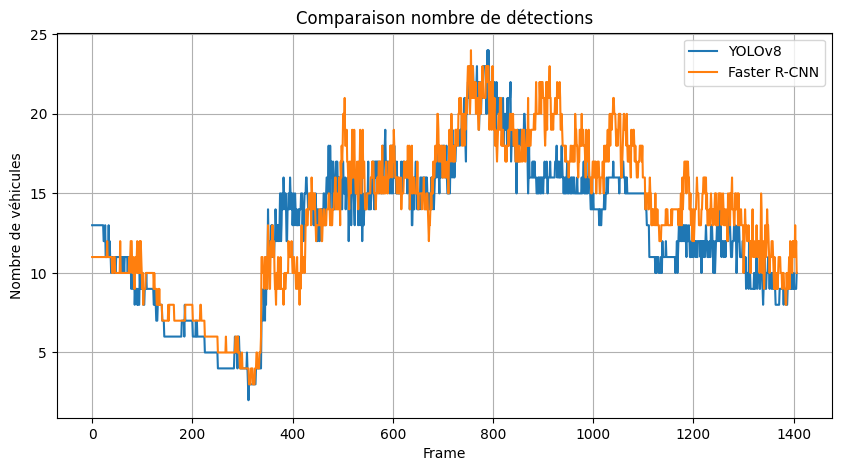

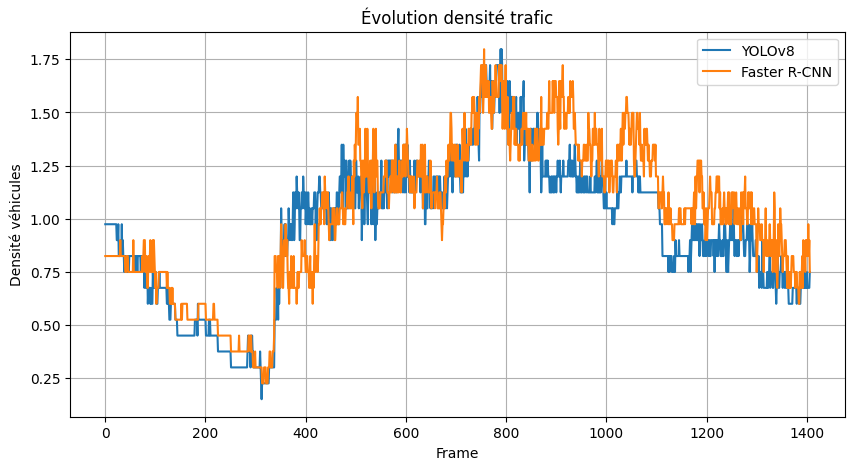

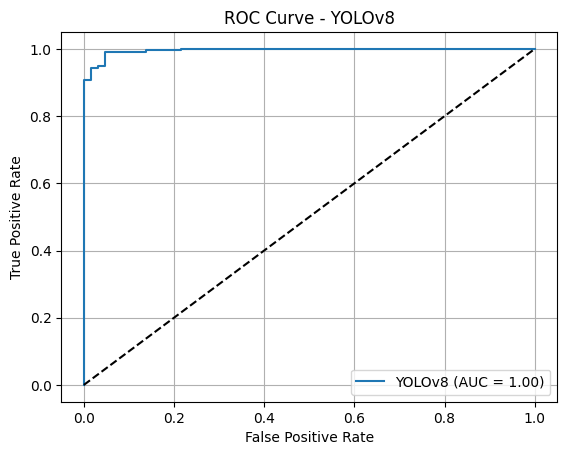

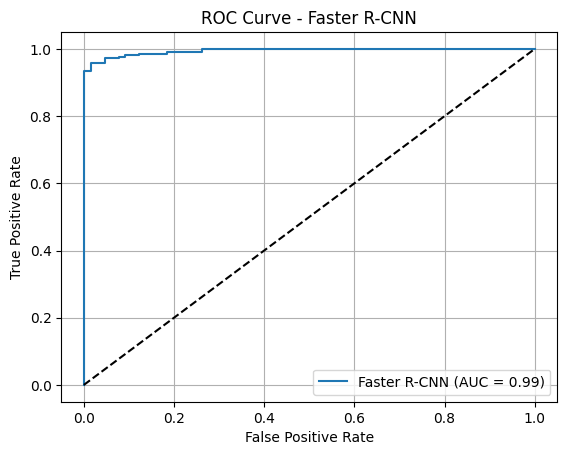

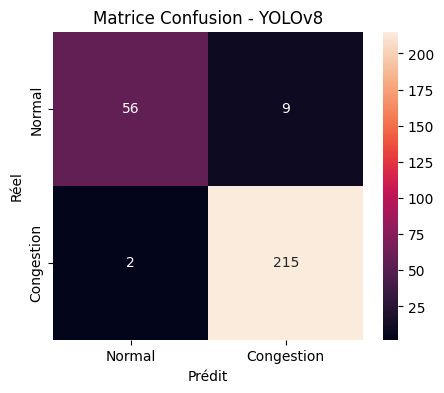

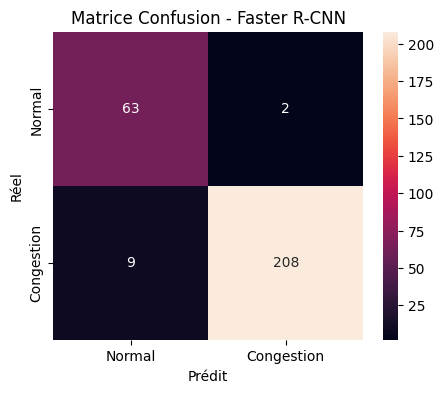


PIPELINE TERMINÉ


In [ ]:
def main():
    """
    Execute le pipeline complet:
    1. Traitement YOLOv8
    2. Traitement Faster R-CNN
    3. Comparaison détections
    4. Entraînement ML YOLOv8
    5. Entraînement ML Faster R-CNN
    6. Comparaison modèles ML
    7. affichage des courbes
    """

    print("\n" + "="*60)
    print("PIPELINE TRAFIC - YOLOv8 vs Faster R-CNN")
    print("="*60)

    roi_coords = (ROI_X1, ROI_Y1, ROI_X2, ROI_Y2)

    # ÉTAPE 1 & 2: Traitement vidéo
    print("\n[ÉTAPE 1-2] Traitement vidéo...")
    df_yolo = pipeline_video_yolo(VIDEO_PATH, YOLO_MODEL_PATH, roi_coords,OUT_VIDEO_YOLO,OUT_CSV_YOLO )
    df_frcnn = pipeline_video_fasterrcnn(VIDEO_PATH, roi_coords)

    # ÉTAPE 3: Comparaison détections
    print("\n[ÉTAPE 3] Comparaison des résultats...")
    df_comparison = comparer_detections(df_yolo, df_frcnn)
    afficher_statistiques_comparaison(df_comparison)

    # ÉTAPE 4-5: ML
    print("\n[ÉTAPE 4-5] Entraînement modèles ML...")
    results_yolo = entrainer_modele_ml(OUT_CSV_YOLO, GT_CSV_PATH, "YOLOv8")
    results_frcnn = entrainer_modele_ml(OUT_CSV_FRCNN, GT_CSV_PATH, "Faster R-CNN")

    # ÉTAPE 6: Affichage résultats
    print("\n[ÉTAPE 6] Résultats ML...")
    afficher_resultats_ml(results_yolo)
    afficher_resultats_ml(results_frcnn)
    comparer_modeles_ml(results_yolo, results_frcnn)

    # affichage des courbes
    print("\n[ÉTAPE 7] Visualisations...")
    afficher_toutes_les_visualisations(df_yolo, df_frcnn, results_yolo, results_frcnn)

    print("\n" + "="*60)
    print("PIPELINE TERMINÉ")
    print("="*60)


if __name__ == "__main__":
    main()

# Testing Yolo with another video

In [ ]:
# ===========================
# VIDEO 2 CONFIG
# ===========================
VIDEO_PATH_2 = "/content/test_video2.mp4"
OUT_VIDEO_YOLO_2 = "/content/output/output_yolo_video2.mp4"
OUT_CSV_YOLO_2 = "/content/output/features_yolo_video2.csv"

# ROI différente pour vidéo 2
ROI2_X1, ROI2_Y1 = 600, 20
ROI2_X2, ROI2_Y2 = 2000, 950

In [ ]:
def main_test_video2():
    """
    Test uniquement la deuxième vidéo avec ROI différente
    """

    print("\n" + "="*60)
    print("TEST ROBUSTESSE - VIDEO 2")
    print("="*60)

    roi_coords2 = (ROI2_X1, ROI2_Y1, ROI2_X2, ROI2_Y2)

    df_yolo_2 = pipeline_video_yolo(
        VIDEO_PATH_2,
        YOLO_MODEL_PATH,
        roi_coords2,
        OUT_VIDEO_YOLO_2,
        OUT_CSV_YOLO_2
    )

    print("\nTraitement vidéo 2 terminé.")
    print(f"CSV sauvegardé : {OUT_CSV_YOLO_2}")
    print(f"Vidéo sauvegardée : {OUT_VIDEO_YOLO_2}")

In [ ]:
if __name__ == "__main__":
    main_test_video2()


TEST ROBUSTESSE - VIDEO 2
Traitement YOLOv8 en cours...
Frame YOLOv8 100 traitée
Frame YOLOv8 200 traitée
Frame YOLOv8 300 traitée
Frame YOLOv8 400 traitée
Frame YOLOv8 500 traitée
Frame YOLOv8 600 traitée
Frame YOLOv8 700 traitée
Frame YOLOv8 800 traitée
Frame YOLOv8 900 traitée
Frame YOLOv8 1000 traitée
Frame YOLOv8 1100 traitée
Frame YOLOv8 1200 traitée
Frame YOLOv8 1300 traitée
Frame YOLOv8 1400 traitée
Frame YOLOv8 1500 traitée
YOLOv8 terminé! CSV: /content/output/features_yolo_video2.csv

Traitement vidéo 2 terminé.
CSV sauvegardé : /content/output/features_yolo_video2.csv
Vidéo sauvegardée : /content/output/output_yolo_video2.mp4


In [ ]:
import shutil

# Remplace par le chemin de ton dossier dans /content
folder_path = "/content/output"
zip_path = "/content/Traffic_Project_output.zip"

# Créer le zip
shutil.make_archive("/content/Traffic_Project_output", 'zip', folder_path)
print("Zip créé :", zip_path)


Zip créé : /content/Traffic_Project_output.zip


In [ ]:
from google.colab import files
files.download(zip_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>